![Homomorphic encryption](assets/headers/homomorphic-encryption.jpg)

# 05. Homomorphic encryption

A clinic wants a heart-disease prediction from a model that runs on someone else's server, but
the server must not see the patient's data. We compile a small decision tree with Concrete ML,
send an encrypted patient record to the server, and decrypt the answer back at the clinic.

**Code co-created by:** Ülkü Tuncer Küçüktaş, Simge Danışoğlu, Tolga Turan, Gizem Acer

## Setup

Tested with Python 3.11 on macOS and Linux (on Windows, use WSL). Concrete ML pins its own
dependencies, so give this notebook its own environment. The next cell installs the package
versions used in this notebook.

In [1]:
%pip install --quiet concrete-ml==1.9.0 numpy==1.26.4 pandas==2.0.3 scikit-learn==1.5.0 \
    matplotlib==3.9.4

Note: you may need to restart the kernel to use updated packages.


In [2]:
import shutil
import time
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from concrete.ml.deployment import FHEModelClient, FHEModelDev, FHEModelServer
from concrete.ml.sklearn import DecisionTreeClassifier as FHEDecisionTreeClassifier
from concrete.ml.sklearn import LogisticRegression as FHELogisticRegression
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Colours used in the figures
NAVY, BLUE, TEAL, GOLD, RED = "#1C3076", "#3457A6", "#168A88", "#C58A00", "#B53B4A"
plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

## 1. Load the patients

We use the Cleveland file of the UCI Heart Disease data: 303 patients with 13 clinical
measurements each. Six patients have missing values and are dropped. The label is 1 when the
patient shows any sign of heart disease (`num > 0`).

In [3]:
UCI_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/"
COLUMNS = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
           "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"]


def load_hospital(filename):
    """Download a UCI heart-disease file once, then read it from data/."""
    path = Path("data") / filename
    if not path.exists():
        path.parent.mkdir(exist_ok=True)
        urllib.request.urlretrieve(UCI_URL + filename, path)
    return pd.read_csv(path, names=COLUMNS, na_values="?")


data = load_hospital("processed.cleveland.data").dropna()
feature_names = COLUMNS[:-1]  # everything except the label column "num"
features = data[feature_names].to_numpy()
labels = (data["num"] > 0).astype(int).to_numpy()

train_X, test_X, train_y, test_y = train_test_split(
    features, labels, test_size=0.2, random_state=0, stratify=labels
)
print(len(data), "patients.  Train:", train_X.shape, " Test:", test_X.shape)

297 patients.  Train: (237, 13)  Test: (60, 13)


## 2. A float tree and its quantized copy

The encrypted circuit can only work on small integers. So Concrete ML maps every input feature
onto an integer with `N_BITS` bits (0 to 63 here) and trains its tree on those integers. This can
change a few predictions, which is why the encrypted result is later compared with the quantized
model run in clear, not with the float tree.

We train an ordinary scikit-learn tree as the float reference and a Concrete ML tree of the same
depth.

In [4]:
MAX_DEPTH = 3  # a shallow tree keeps the encrypted circuit small
N_BITS = 6  # inputs and thresholds become integers from 0 to 2**6 - 1

float_tree = DecisionTreeClassifier(max_depth=MAX_DEPTH, random_state=0).fit(train_X, train_y)
quant_tree = FHEDecisionTreeClassifier(max_depth=MAX_DEPTH, n_bits=N_BITS, random_state=0)
quant_tree.fit(train_X, train_y)

float_pred = float_tree.predict(test_X)
quant_pred = quant_tree.predict(test_X, fhe="disable")  # the integer model, without encryption

print(f"Test accuracy, float tree:     {accuracy_score(test_y, float_pred):.4f}")
print(f"Test accuracy, quantized tree: {accuracy_score(test_y, quant_pred):.4f}")
print(f"Same prediction for {np.sum(float_pred == quant_pred)} of {len(test_y)} test patients "
      f"({np.mean(float_pred == quant_pred):.4f})")

Test accuracy, float tree:     0.7833
Test accuracy, quantized tree: 0.7667
Same prediction for 59 of 60 test patients (0.9833)


This is what the circuit receives for the first test patient. Each feature is mapped onto the
range 0 to 63 using the values seen in training.

In [5]:
patient = test_X[:1]
# dtype=object keeps the second row as integers instead of 22.0, 63.0, ...
pd.DataFrame([patient[0], quant_tree.quantize_input(patient)[0]],
             index=["value", f"{N_BITS}-bit integer"], columns=feature_names, dtype=object)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
value,46.0,1.0,3.0,150.0,231.0,0.0,0.0,147.0,0.0,3.6,2.0,0.0,3.0
6-bit integer,22,63,42,33,15,0,0,37,0,37,31,0,0


The float tree is small enough to read. Each box shows how many training patients reach it,
how they split into [no disease, disease], and the class it predicts. The first split is on
`thal`, the thallium stress test (3 = normal, 6 = fixed defect, 7 = reversible defect), so
`thal <= 4.5` means a normal result. Below it come `ca` (number of major vessels seen on
fluoroscopy), `oldpeak` (ST depression during exercise), `cp` (chest pain type), `trestbps`
(resting blood pressure) and `chol` (cholesterol).

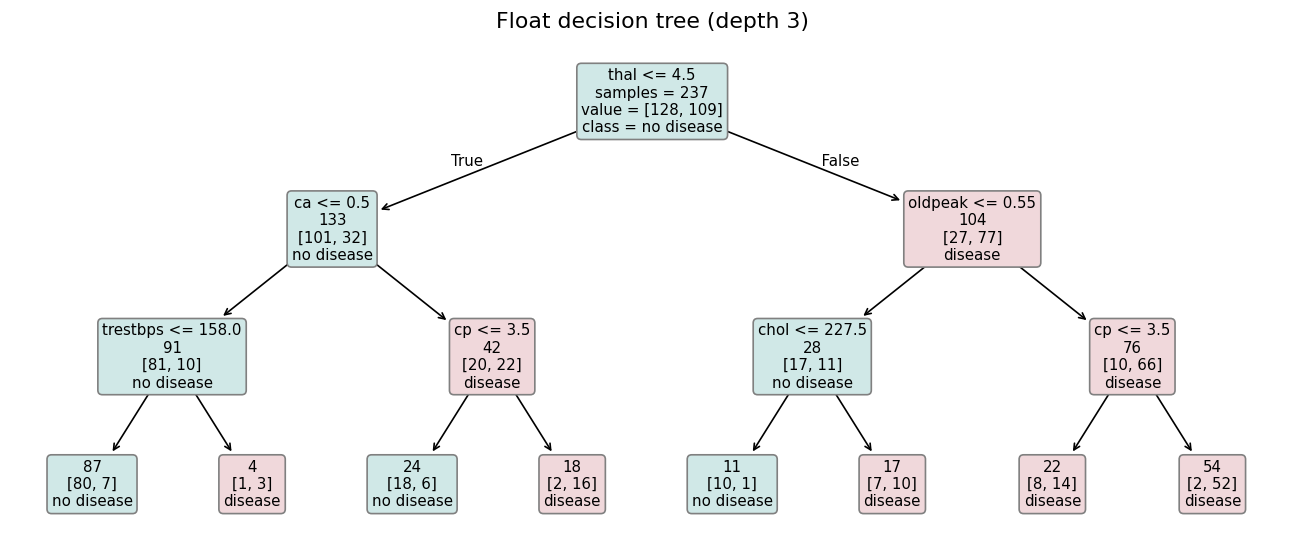

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.8))
nodes = plot_tree(float_tree, feature_names=feature_names, class_names=["no disease", "disease"],
                  label="root", impurity=False, rounded=True, fontsize=9, ax=ax)
for node in nodes:  # colour each box by its predicted class (arrows have no box)
    if node.get_bbox_patch():
        colour = "#D0E8E7" if node.get_text().endswith("no disease") else "#F0D8DB"
        node.get_bbox_patch().set(facecolor=colour, edgecolor="grey")
        # scikit-learn prints some counts as 128.0; show them all as whole numbers
        node.set_text(node.get_text().replace(".0,", ",").replace(".0]", "]"))
ax.set_title(f"Float decision tree (depth {MAX_DEPTH})")
fig.tight_layout()
plt.show()

Concrete ML's tree was trained on the 6-bit features, so its splits fall on the integer grid and
can differ slightly from the ones above. That is where the one changed test prediction comes
from.

## 3. Compile the model into an encrypted circuit

Compiling turns the quantized tree into a circuit of operations on encrypted integers. Concrete
ML uses the TFHE scheme, where each comparison in the tree becomes an encrypted table lookup.
The server cannot see which branch the patient takes, so it evaluates every comparison in the
tree, not just one path.
The training data is used to check the range of every intermediate value. `p_error` is the
allowed probability that a single table lookup returns a wrong value.

In [7]:
start = time.perf_counter()
quant_tree.compile(train_X, p_error=1e-6)
compile_s = time.perf_counter() - start
print(f"Compiled in {compile_s:.2f} s")

Compiled in 0.96 s


## 4. Developer, server and clinic

Three parties take part. In a real deployment they are separate machines. Here they share one
Python process, but each gets its own folder under `generated/05_homomorphic_encryption/tree/`,
so you can see what it holds.

| Folder | Receives | What is inside |
| --- | --- | --- |
| `developer/` | the compiled model | `client.zip` and `server.zip`, written by `FHEModelDev` |
| `server/` | `server.zip` only | the compiled circuit |
| `clinic/` | `client.zip` only | the encryption parameters and the quantization settings |

The clinic's package does not contain the tree. The server's package does: the thresholds are
constants inside the circuit, so encryption hides the patient from the server, not the model.

The clinic then creates its keys locally. The secret key encrypts and decrypts, and it never
leaves `clinic/keys/`. The evaluation keys let the server compute on ciphertexts without being
able to read them. They are the only keys the clinic sends.

In [8]:
DEPLOY_DIR = Path("generated/05_homomorphic_encryption")


def deploy(model, folder):
    """Save a compiled model as the developer, then give the server and the clinic their part."""
    shutil.rmtree(folder, ignore_errors=True)  # FHEModelDev only writes into an empty folder
    FHEModelDev(folder / "developer", model).save()

    (folder / "server").mkdir()
    shutil.copy(folder / "developer" / "server.zip", folder / "server")
    (folder / "clinic").mkdir()
    shutil.copy(folder / "developer" / "client.zip", folder / "clinic")

    server = FHEModelServer(folder / "server")
    client = FHEModelClient(folder / "clinic", key_dir=folder / "clinic" / "keys")
    return client, server


tree_dir = DEPLOY_DIR / "tree"
client, server = deploy(quant_tree, tree_dir)

# The clinic generates its secret key and the evaluation keys. Only eval_keys goes to the server.
start = time.perf_counter()
eval_keys = client.get_serialized_evaluation_keys()
keygen_s = time.perf_counter() - start
print(f"Key generation: {keygen_s:.2f} s")
print(f"Evaluation keys for the server: {len(eval_keys):,} bytes\n")

for role in ["developer", "server", "clinic"]:
    print(f"{role}/".ljust(13), sorted(path.name for path in (tree_dir / role).iterdir()))
# Concrete ML stores the key files one level down, in a folder named after the key set
print("clinic/keys/ ", sorted(path.name for path in (tree_dir / "clinic" / "keys").glob("*/*")))

Key generation: 0.65 s
Evaluation keys for the server: 53,887,760 bytes

developer/    ['client.zip', 'server.zip']
server/       ['server.zip']
clinic/       ['client.zip', 'keys']
clinic/keys/  ['ksKey_0', 'ksKey_1', 'pbsKey_0', 'pbsKey_1', 'pbsKey_2', 'secretKey_0', 'secretKey_1', 'secretKey_2', 'secretKey_3', 'secretKey_4']


KeySetCache: miss, regenerating generated/05_homomorphic_encryption/tree/clinic/keys/18194400113098654531


The `secretKey_*` files stay at the clinic. The key-switching (`ksKey_*`) and bootstrapping
(`pbsKey_*`) keys are the evaluation keys that were serialized into `eval_keys` for the server.
The `KeySetCache: miss` line is Concrete reporting that it found no keys in `clinic/keys/` and
created new ones.

## 5. Encrypt at the clinic, compute at the server, decrypt at the clinic

![One encrypted prediction: the clinic encrypts, the server computes, the clinic decrypts](assets/figures/05_round_trip.png)

Only three things cross the network: the evaluation keys (once), the encrypted patient record
and the encrypted result. The server never sees the patient's values or the prediction in
readable form.

`encrypted_predict` runs steps 1 to 4 for one patient and times the clinic and server parts
separately. Compilation and key generation happen once and are not part of it.

In [9]:
def encrypted_predict(client, server, eval_keys, row):
    """Send one patient through clinic -> server -> clinic. Returns the class and stage times."""
    # 1. Clinic: quantize the row and encrypt it with the secret key
    start = time.perf_counter()
    encrypted_row = client.quantize_encrypt_serialize(row.reshape(1, -1))
    encrypt_s = time.perf_counter() - start

    # 2-3. Server: run the circuit on the ciphertext with the evaluation keys, return the result
    start = time.perf_counter()
    encrypted_result = server.run(encrypted_row, eval_keys)
    server_s = time.perf_counter() - start

    # 4. Clinic: decrypt the class probabilities and pick the larger one
    start = time.perf_counter()
    probabilities = client.deserialize_decrypt_dequantize(encrypted_result)
    decrypt_s = time.perf_counter() - start

    return int(probabilities.argmax()), encrypt_s, server_s, decrypt_s

In [10]:
N_PATIENTS = 3  # encrypted predictions to run

rows = []
for i in range(N_PATIENTS):
    encrypted_pred, encrypt_s, server_s, decrypt_s = encrypted_predict(
        client, server, eval_keys, test_X[i]
    )

    # The same quantized tree without encryption, as the reference and for timing
    start = time.perf_counter()
    clear_pred = quant_tree.predict(test_X[i : i + 1], fhe="disable")[0]
    clear_s = time.perf_counter() - start

    rows.append([i + 1, test_y[i], clear_pred, encrypted_pred,
                 clear_s, encrypt_s, server_s, decrypt_s])

columns = ["patient", "true label", "clear", "encrypted",
           "clear s", "encrypt s", "server s", "decrypt s"]
results = pd.DataFrame(rows, columns=columns).set_index("patient")
same = (results["encrypted"] == results["clear"]).sum()
print(f"Encrypted and clear quantized predictions agree for {same}/{N_PATIENTS} patients")
results.round(4)

Encrypted and clear quantized predictions agree for 3/3 patients


,true label,clear,encrypted,clear s,encrypt s,server s,decrypt s
patient,,,,,,,
1,1,0,0,0.0008,0.0020,1.0649,0.0017
2,1,1,1,0.0003,0.0040,0.4673,0.0010
3,1,1,1,0.0003,0.0024,0.3771,0.0009


Patient 1 has heart disease, and both the clear and the encrypted model miss it. The encrypted
result matches the quantized model, including its mistakes. With `p_error = 1e-6` a mismatch is
possible but very unlikely.

## 6. The cost of encryption

Computing on encrypted data has a price: slower operations, larger values and more memory.
First the time. The y-axis is logarithmic: each tick is ten times the one below.

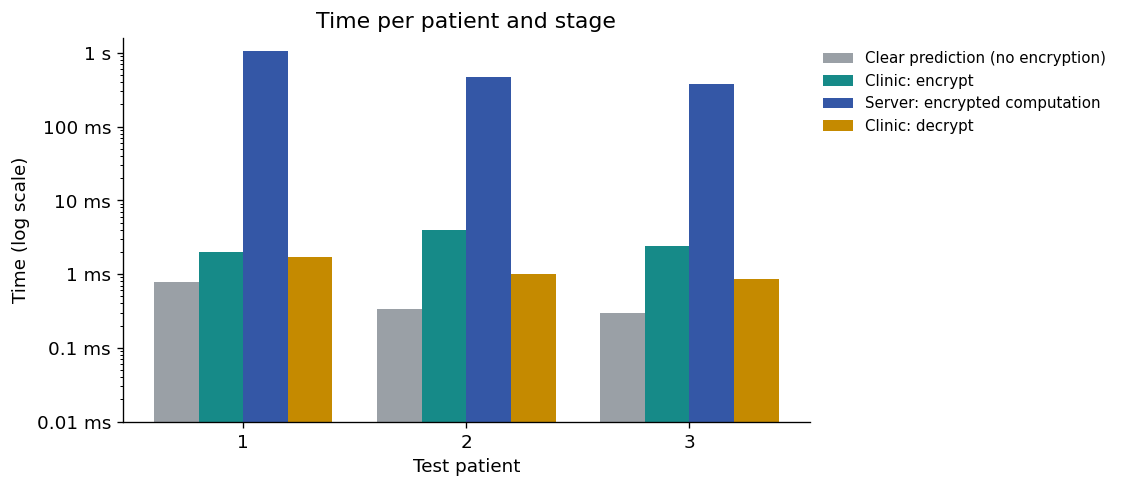

In [11]:
PLAIN = "#9AA0A6"  # grey for anything computed or stored without encryption
stages = [("clear s", "Clear prediction (no encryption)", PLAIN),
          ("encrypt s", "Clinic: encrypt", TEAL),
          ("server s", "Server: encrypted computation", BLUE),
          ("decrypt s", "Clinic: decrypt", GOLD)]
x = np.arange(N_PATIENTS)
width = 0.2

fig, ax = plt.subplots(figsize=(9.5, 4.2))
for k, (column, label, colour) in enumerate(stages):
    ax.bar(x + (k - 1.5) * width, results[column], width, label=label, color=colour)
ax.set_yscale("log")
ax.set_ylim(bottom=1e-5)  # bars start at 0.01 ms, below the fastest stage
ax.yaxis.set_major_formatter(lambda t, _: f"{t * 1000:g} ms" if t < 1 else f"{t:g} s")
ax.set(xticks=x, xticklabels=results.index, xlabel="Test patient",
       ylabel="Time (log scale)", title="Time per patient and stage")
ax.legend(fontsize=9, loc="upper left", bbox_to_anchor=(1, 1), frameon=False)
fig.tight_layout()
plt.show()

The server's first run is slower than the rest because of one-time start-up work in the
runtime. Run the loop in section 5 again and every patient takes about the same time. The
summary numbers below, and in the optional part, use the median, which ignores that one slow run.

In [12]:
slowdown = results["server s"].median() / results["clear s"].median()
print(f"The encrypted computation is about {slowdown:,.0f} times slower than the clear prediction "
      f"(median over {N_PATIENTS} patients)")

The encrypted computation is about 1,398 times slower than the clear prediction (median over 3 patients)


Now the size. We run one more round trip and keep the ciphertexts this time.

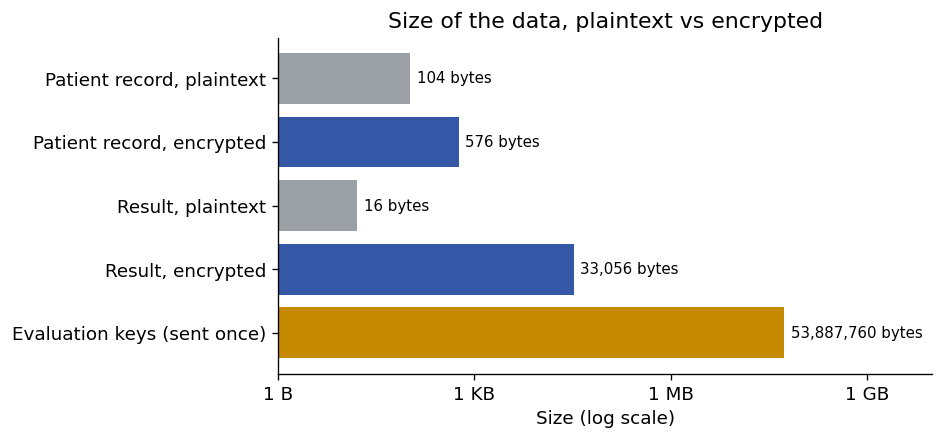

In [13]:
row = test_X[:1]
encrypted_row = client.quantize_encrypt_serialize(row)
encrypted_result = server.run(encrypted_row, eval_keys)
probabilities = client.deserialize_decrypt_dequantize(encrypted_result)

sizes = {"Patient record, plaintext": row.nbytes,
         "Patient record, encrypted": len(encrypted_row),
         "Result, plaintext": probabilities.nbytes,
         "Result, encrypted": len(encrypted_result),
         "Evaluation keys (sent once)": len(eval_keys)}

fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.barh(list(sizes), list(sizes.values()), color=[PLAIN, BLUE, PLAIN, BLUE, GOLD])
ax.bar_label(bars, labels=[f"{n:,} bytes" for n in sizes.values()], padding=4, fontsize=9)
ax.set_xscale("log")
ax.set_xlim(1, 1e10)
ax.set_xticks([1, 1e3, 1e6, 1e9], ["1 B", "1 KB", "1 MB", "1 GB"])
ax.invert_yaxis()
ax.set(xlabel="Size (log scale)", title="Size of the data, plaintext vs encrypted")
fig.tight_layout()
plt.show()

The encrypted record stays small because Concrete ML compresses fresh ciphertexts and keys: their
random part is regenerated from a short seed. The result that comes back from the server cannot
be compressed this way. The evaluation keys are by far the largest item, but the clinic sends
them once, not with every patient.

## Optional: Decision tree vs logistic regression

Homomorphic schemes differ in the operations they support. Partially homomorphic encryption
supports one operation: Paillier, for example, can only add encrypted values. Fully homomorphic
encryption supports both addition and multiplication, and so it can express any computation.

| Scheme | Type | Works on | Good for |
| --- | --- | --- | --- |
| Paillier | partially HE | integers, addition only | encrypted sums, averages, linear scores |
| BFV / BGV | fully HE | exact integers | counts and integer arithmetic |
| CKKS | fully HE | approximate real numbers | linear algebra with a small numeric error |
| TFHE (Concrete ML) | fully HE | small integers, table lookups | comparisons, trees, quantized models |

The model matters as much as the scheme. A logistic regression score is a weighted sum of the
inputs, which needs only additions and multiplications by the clear weights. The sigmoid is
applied by the clinic after decryption. A tree needs comparisons, and TFHE evaluates each one
with a table lookup (programmable bootstrapping), which is far more expensive.

Below, a logistic regression goes through the same round trip, using the same `deploy` and
`encrypted_predict` functions as the tree.

In [14]:
# Logistic regression needs scaled features. Fit the scaler on the training patients only.
scaler = StandardScaler().fit(train_X)
train_scaled, test_scaled = scaler.transform(train_X), scaler.transform(test_X)

float_logreg = LogisticRegression(max_iter=2000, random_state=0).fit(train_scaled, train_y)
quant_logreg = FHELogisticRegression(n_bits=8, max_iter=2000, random_state=0)
quant_logreg.fit(train_scaled, train_y)

start = time.perf_counter()
quant_logreg.compile(train_scaled, p_error=1e-6)
logreg_compile_s = time.perf_counter() - start

logreg_client, logreg_server = deploy(quant_logreg, DEPLOY_DIR / "logistic_regression")
start = time.perf_counter()
logreg_keys = logreg_client.get_serialized_evaluation_keys()
logreg_keygen_s = time.perf_counter() - start

runs = [encrypted_predict(logreg_client, logreg_server, logreg_keys, row)
        for row in test_scaled[:N_PATIENTS]]
logreg_runs = pd.DataFrame(runs, columns=["encrypted", "encrypt s", "server s", "decrypt s"])
logreg_runs["clear"] = quant_logreg.predict(test_scaled[:N_PATIENTS], fhe="disable")

KeySetCache: miss, regenerating generated/05_homomorphic_encryption/logistic_regression/clinic/keys/17586329962004342717


,float accuracy,quantized accuracy,encrypted = clear,evaluation keys (bytes),compile s,key generation s,median round trip s
Decision tree,0.7833,0.7667,3/3,53887760,0.9595,0.6524,0.4723
Logistic regression,0.8500,0.8500,3/3,64,0.1149,0.0005,0.0162


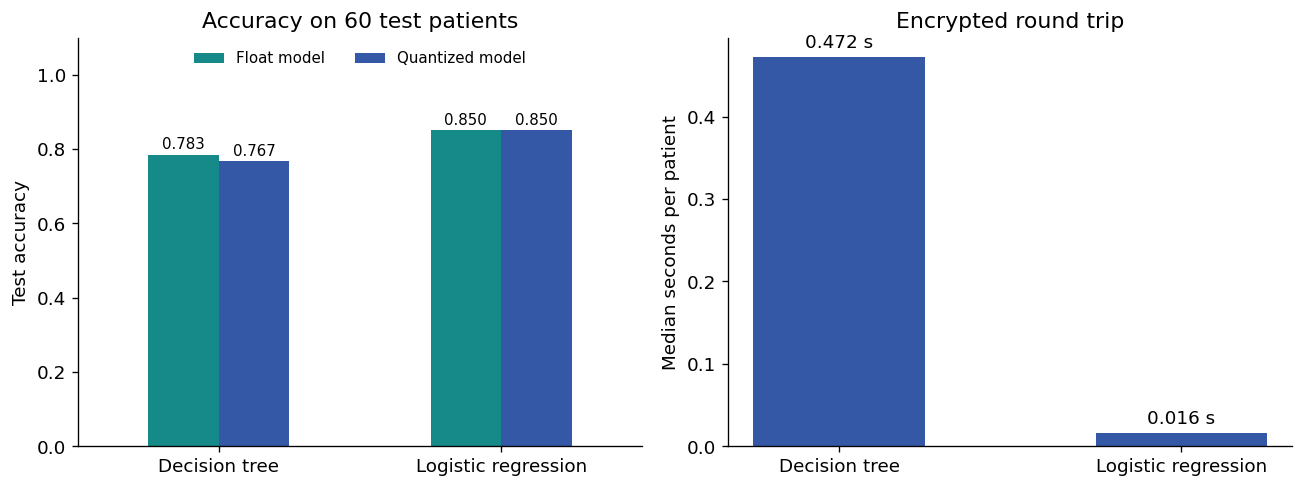

In [15]:
stage_columns = ["encrypt s", "server s", "decrypt s"]
logreg_same = (logreg_runs["encrypted"] == logreg_runs["clear"]).sum()
logreg_float_pred = float_logreg.predict(test_scaled)
logreg_quant_pred = quant_logreg.predict(test_scaled, fhe="disable")

comparison = pd.DataFrame({
    "float accuracy": [accuracy_score(test_y, float_pred),
                       accuracy_score(test_y, logreg_float_pred)],
    "quantized accuracy": [accuracy_score(test_y, quant_pred),
                           accuracy_score(test_y, logreg_quant_pred)],
    "encrypted = clear": [f"{same}/{N_PATIENTS}", f"{logreg_same}/{N_PATIENTS}"],
    "evaluation keys (bytes)": [len(eval_keys), len(logreg_keys)],
    "compile s": [compile_s, logreg_compile_s],
    "key generation s": [keygen_s, logreg_keygen_s],
    "median round trip s": [results[stage_columns].sum(axis=1).median(),
                            logreg_runs[stage_columns].sum(axis=1).median()],
}, index=["Decision tree", "Logistic regression"])
display(comparison.round(4))

fig, (acc_ax, time_ax) = plt.subplots(1, 2, figsize=(11, 4.2))
comparison[["float accuracy", "quantized accuracy"]].plot.bar(ax=acc_ax, rot=0, color=[TEAL, BLUE])
for bars in acc_ax.containers:
    acc_ax.bar_label(bars, fmt="%.3f", fontsize=9, padding=2)
acc_ax.set(ylim=(0, 1.1), ylabel="Test accuracy", title=f"Accuracy on {len(test_y)} test patients")
acc_ax.legend(["Float model", "Quantized model"], fontsize=9, loc="upper center", ncols=2,
              frameon=False)

bars = time_ax.bar(comparison.index, comparison["median round trip s"], color=BLUE, width=0.5)
time_ax.bar_label(bars, fmt="%.3f s", padding=3)
time_ax.set(ylabel="Median seconds per patient", title="Encrypted round trip")
fig.tight_layout()
plt.show()

Under encryption, both models return exactly their clear predictions for these patients. The
linear model is also the more accurate one on this data. Its encrypted round trip is much faster
and its evaluation keys shrink to 64 bytes, because a weighted sum needs no bootstrapping, while
every comparison in the tree does.

## Experiments

1. Set `N_BITS = 4` in section 2 and run the notebook again from there. How do the quantized
   accuracy and the server time change?
2. Try `MAX_DEPTH = 5`. A deeper tree has more comparisons for the server to evaluate. Watch the
   compile time and the server time.
3. Set `N_PATIENTS = 20`. Does the encrypted prediction still match the clear one for every
   patient?
4. In the optional part, give the logistic regression `n_bits=4` and compare its accuracy with
   the 8-bit version.

**References:** [Concrete ML client/server](https://docs.zama.org/concrete-ml/guides/client_server) ·
[Concrete ML tree models](https://docs.zama.org/concrete-ml/built-in-models/tree) ·
[Chillotti et al., TFHE (2020)](https://eprint.iacr.org/2018/421) ·
[Gentry, A fully homomorphic encryption scheme (2009)](https://crypto.stanford.edu/craig/craig-thesis.pdf) ·
[UCI Heart Disease data](https://archive.ics.uci.edu/dataset/45/heart+disease)